# Load and prepare all datasets

# 1. Data Sources & Provenance

### 1.1 Base Datasets (Raw)
The following datasets were used in their raw format directly from Kaggle. Click the Source ID to view the original repository. 

*(Note: The "Room Occupancy" dataset (DATA 1) was renamed locally to `room_conditions.csv` to match project conventions.)*

| ID | Dataset Focus | Relative Path | 
| :--- | :--- | :--- | 
| [DATA 1](https://www.kaggle.com/datasets/tombutton/roomoccupancy) | Room Occupancy | `data/raw/room_conditions.csv` | 
| [DATA 2](https://www.kaggle.com/datasets/colabsss/ai-iot-agile-teaching-dataset/data) | Agile Teaching | `data/raw/agile_teaching_dataset.csv` | 
| [DATA 3](https://www.kaggle.com/datasets/ziya07/environmental-design-iotml-dataset) | Environmental Design | `data/raw/environmental_design_dataset.csv` | 
| [DATA 4](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset/data) | Green Building | `data/raw/green_building_dataset.csv` | 
| [DATA 5](https://www.kaggle.com/datasets/ziya07/iot-based-environmental-dataset/data) | Univ. Mental Health | `data/raw/university_mental_health_iot_dataset.csv` | 

### 1.2 The KETI Smart Building Dataset (Interim)
[DATA 6 (Smart Building System)](https://www.kaggle.com/datasets/ranakrc/smart-building-system) originally consisted of 50+ individual CSV files distributed across multiple folders inside `data/raw/KETI/`. 

1. **Aggregation & Alignment:** Parsed Unix timestamps and merged the distributed, asynchronous sensor CSVs into a single file (`combined_keti_sensor_data.csv`).
2. **Feature Engineering:** Binarized the Passive Infrared (PIR) motion sensor data. Values originally ranging from 0–30 (and anomalous spikes) were normalized to standard boolean triggers (0 = vacant, 1 = occupied).
3. **Resampling:** Resampled the entire dataset to a standardized 1-minute frequency, applying statistical aggregations (`mean` for continuous sensors, `max` for boolean motion).
4. **Data Cleaning (Imputation):** Handled any remaining missing values (NaNs) in the 1-minute grid using forward-fill (carrying the last known sensor reading forward) and backward-fill techniques.

The final time-aligned data used for this analysis is located at: `data/interim/keti_1min_resampled.csv`.

In [64]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data 1

In [65]:
data_1 = pd.read_csv('../data/raw/room_conditions.csv')
data_1.head()

,id,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,140,02/02/15 14:19,23.7000,26.272,585.200000,749.200000,0.004764,1
1,141,02/02/15 14:19,23.7180,26.290,578.400000,760.400000,0.004773,1
2,142,02/02/15 14:21,23.7300,26.230,572.666667,769.666667,0.004765,1
3,143,02/02/15 14:22,23.7225,26.125,493.750000,774.750000,0.004744,1
4,144,02/02/15 14:23,23.7540,26.200,488.600000,779.000000,0.004767,1


In [66]:
data_1 = data_1.drop(columns=['id','Occupancy', 'HumidityRatio'])
data_1 = data_1.rename(columns={'Temperature': 'temperature', 'Humidity': 'humidity', 'Light': 'light', 'CO2': 'co2', 'date':'timestamp'})
data_1.head()

,timestamp,temperature,humidity,light,co2
0,02/02/15 14:19,23.7000,26.272,585.200000,749.200000
1,02/02/15 14:19,23.7180,26.290,578.400000,760.400000
2,02/02/15 14:21,23.7300,26.230,572.666667,769.666667
3,02/02/15 14:22,23.7225,26.125,493.750000,774.750000
4,02/02/15 14:23,23.7540,26.200,488.600000,779.000000


In [67]:
# Analyze the ranges of individual features
print("Data 1 Ranges:")
print(data_1.describe())

Data 1 Ranges:
       temperature     humidity        light          co2
count  2665.000000  2665.000000  2665.000000  2665.000000
mean     21.433876    25.353937   193.227556   717.906470
std       1.028024     2.436842   250.210906   292.681718
min      20.200000    22.100000     0.000000   427.500000
25%      20.650000    23.260000     0.000000   466.000000
50%      20.890000    25.000000     0.000000   580.500000
75%      22.356667    26.856667   442.500000   956.333333
max      24.408333    31.472500  1697.250000  1402.250000


Every 1-2 minutes

## Data 2

In [68]:
data_2 = pd.read_csv('../data/raw/agile_teaching_dataset.csv')
data_2.head()

,student_id,timestamp,heart_rate,skin_temp,movement_level,focus_score,emotional_state,ambient_light,ambient_noise,temperature,humidity,board_interaction,learning_material_access,quiz_score,assignment_completion,participation_level,target
0,1047,2024-09-01 08:00:00,99,36.3,2.07,0.45,stressed,264,59,25.9,38.2,12,12,61,59,5,0
1,1008,2024-09-01 08:01:00,114,36.3,8.63,0.39,neutral,628,37,29.9,54.8,33,5,13,16,2,0
2,1068,2024-09-01 08:02:00,87,36.9,6.48,0.63,happy,772,69,21.6,50.7,18,4,91,94,0,1
3,1004,2024-09-01 08:03:00,113,37.9,4.68,0.84,neutral,621,37,26.6,65.8,19,8,7,61,8,1
4,1093,2024-09-01 08:04:00,70,37.6,9.47,0.68,happy,648,46,23.3,31.2,2,11,81,88,9,0


In [69]:
# We only take columns we need
data_2 = data_2[['timestamp', 'temperature', 'ambient_light', 'humidity', 'ambient_noise','focus_score', 'student_id']]
data_2 = data_2.rename(columns={'timestamp': 'timestamp', 'focus_score': 'score', 'ambient_light': 'light', 'ambient_noise': 'noise', 'temperature': 'temperature', 'humidity': 'humidity', 'student_id':'id'})
data_2.head()

,timestamp,temperature,light,humidity,noise,score,id
0,2024-09-01 08:00:00,25.9,264,38.2,59,0.45,1047
1,2024-09-01 08:01:00,29.9,628,54.8,37,0.39,1008
2,2024-09-01 08:02:00,21.6,772,50.7,69,0.63,1068
3,2024-09-01 08:03:00,26.6,621,65.8,37,0.84,1004
4,2024-09-01 08:04:00,23.3,648,31.2,46,0.68,1093


In [70]:
# Analyze the ranges of individual features
print("Data 2 Ranges:")
print(data_2.describe())

Data 2 Ranges:
       temperature        light     humidity        noise        score  \
count  3500.000000  3500.000000  3500.000000  3500.000000  3500.000000   
mean     24.978657   547.854857    50.288857    54.440286     0.504109   
std       2.858970   257.386272    11.624149    14.501417     0.287990   
min      20.000000   100.000000    30.000000    30.000000     0.000000   
25%      22.500000   322.750000    40.000000    42.000000     0.260000   
50%      25.000000   542.000000    50.500000    54.000000     0.510000   
75%      27.500000   774.000000    60.500000    67.000000     0.750000   
max      30.000000   999.000000    70.000000    79.000000     1.000000   

                id  
count  3500.000000  
mean   1049.053143  
std      29.226555  
min    1000.000000  
25%    1024.000000  
50%    1049.000000  
75%    1075.000000  
max    1099.000000  


In [71]:
data_2 = data_2.sort_values(
    by=["id", "timestamp"],
    ascending=[True, True]
).reset_index(drop=True)

data_2

,timestamp,temperature,light,humidity,noise,score,id
0,2024-09-01 08:28:00,28.0,627,54.8,71,0.08,1000
1,2024-09-01 09:40:00,25.8,938,46.3,59,0.40,1000
2,2024-09-01 12:26:00,26.6,593,57.2,30,0.27,1000
3,2024-09-01 12:50:00,21.3,647,64.3,37,0.03,1000
4,2024-09-01 17:21:00,23.9,390,42.2,75,0.65,1000
...,...,...,...,...,...,...,...
3495,2024-09-03 07:58:00,25.6,674,52.6,60,0.84,1099
3496,2024-09-03 09:12:00,29.8,927,36.3,52,0.96,1099
3497,2024-09-03 11:00:00,26.9,266,35.4,70,0.70,1099
3498,2024-09-03 13:02:00,28.1,646,34.2,57,0.78,1099


Every app 2 hours

## Data 3

In [72]:
data_3 = pd.read_csv('../data/raw/environmental_design_dataset.csv')
data_3.head()

,Timestamp,Sensor_ID,Zone,Temp,Humidity,CO2,PM25,Illuminance,Sound,PMV,PPD,DA,AAI,NDVI,Comfort_Score,AQI_Class
0,2024-01-01 00:00:00,S1,Room1,27.025712,47.764121,550.076658,26.502355,374.689685,44.074750,-0.230611,9.612227,37.468969,0.440747,0.590214,0.923130,Good
1,2024-01-01 00:00:00,S2,Room2,25.046120,42.021709,710.304919,15.071982,384.835844,41.317915,-0.130608,14.612158,38.483584,0.413179,0.326628,0.956464,Good
2,2024-01-01 00:00:00,S3,Room3,25.970129,48.071642,579.443408,21.093931,412.939968,37.560666,-0.010097,9.201943,41.293997,0.375607,0.338391,0.996634,Good
3,2024-01-01 01:00:00,S1,Room1,24.184103,53.923401,634.833416,25.220088,370.466555,52.164802,-0.446075,16.921499,37.046655,0.521648,0.595466,0.851308,Good
4,2024-01-01 01:00:00,S2,Room2,25.668486,51.190183,608.683784,8.474166,474.304387,50.166251,-0.168455,8.369094,47.430439,0.501663,0.695018,0.943848,Moderate


In [73]:
# We only take columns we need
data_3 = data_3[['Timestamp', 'Temp', 'Illuminance', 'Humidity', 'Sound','Comfort_Score', 'Zone', 'CO2']]
data_3 = data_3.rename(columns={'CO2': 'co2', 'Timestamp': 'timestamp', 'Temp': 'temperature', 'Illuminance': 'light', 'Humidity': 'humidity', 'Sound': 'noise', 'Comfort_Score': 'score', 'Zone':'id'})
data_3.head()

,timestamp,temperature,light,humidity,noise,score,id,co2
0,2024-01-01 00:00:00,27.025712,374.689685,47.764121,44.074750,0.923130,Room1,550.076658
1,2024-01-01 00:00:00,25.046120,384.835844,42.021709,41.317915,0.956464,Room2,710.304919
2,2024-01-01 00:00:00,25.970129,412.939968,48.071642,37.560666,0.996634,Room3,579.443408
3,2024-01-01 01:00:00,24.184103,370.466555,53.923401,52.164802,0.851308,Room1,634.833416
4,2024-01-01 01:00:00,25.668486,474.304387,51.190183,50.166251,0.943848,Room2,608.683784


keeping zone to be able to later differentiate between sessions

In [74]:
# Analyze the ranges of individual features
print("Data 3 Ranges:")
print(data_3.describe())

Data 3 Ranges:
       temperature        light     humidity        noise        score  \
count  6480.000000  6480.000000  6480.000000  6480.000000  6480.000000   
mean     23.996993   399.008850    49.935120    44.959575     0.905780   
std       1.994405    99.964757     5.014264     4.997641     0.049113   
min      16.422100    45.596503    31.147424    26.139401     0.701137   
25%      22.678479   331.949176    46.445454    41.658532     0.872701   
50%      24.016557   399.129691    49.963161    45.030719     0.906841   
75%      25.358935   466.021791    53.339895    48.261781     0.941833   
max      32.381474   760.859779    68.872041    65.586189     0.999969   

               co2  
count  6480.000000  
mean    600.334797  
std      98.173147  
min     202.931310  
25%     534.246130  
50%     601.098692  
75%     666.931123  
max     970.935687  


In [75]:
data_3.head()

,timestamp,temperature,light,humidity,noise,score,id,co2
0,2024-01-01 00:00:00,27.025712,374.689685,47.764121,44.074750,0.923130,Room1,550.076658
1,2024-01-01 00:00:00,25.046120,384.835844,42.021709,41.317915,0.956464,Room2,710.304919
2,2024-01-01 00:00:00,25.970129,412.939968,48.071642,37.560666,0.996634,Room3,579.443408
3,2024-01-01 01:00:00,24.184103,370.466555,53.923401,52.164802,0.851308,Room1,634.833416
4,2024-01-01 01:00:00,25.668486,474.304387,51.190183,50.166251,0.943848,Room2,608.683784


In [76]:
data_3 = data_3.sort_values(
    by=["id", "timestamp"],
    ascending=[True, True]
).reset_index(drop=True)

data_3

,timestamp,temperature,light,humidity,noise,score,id,co2
0,2024-01-01 00:00:00,27.025712,374.689685,47.764121,44.074750,0.923130,Room1,550.076658
1,2024-01-01 01:00:00,24.184103,370.466555,53.923401,52.164802,0.851308,Room1,634.833416
2,2024-01-01 02:00:00,24.468516,436.373388,58.113198,48.095827,0.854746,Room1,618.234266
3,2024-01-01 03:00:00,23.425094,447.704086,53.050313,41.934151,0.827065,Room1,540.096374
4,2024-01-01 04:00:00,22.932697,462.676610,52.888536,46.958257,0.885484,Room1,772.613138
...,...,...,...,...,...,...,...,...
6475,2024-03-30 19:00:00,24.954160,283.670614,53.236975,45.318896,0.883140,Room3,346.749947
6476,2024-03-30 20:00:00,24.369379,353.895603,50.787839,42.978536,0.888062,Room3,675.598190
6477,2024-03-30 21:00:00,21.971349,168.864278,50.550681,46.626262,0.858119,Room3,518.977636
6478,2024-03-30 22:00:00,24.795750,259.220629,47.159906,42.900978,0.942290,Room3,748.501975


Every 1hr

## Data 4

In [77]:
data_4 = pd.read_csv('../data/raw/green_building_dataset.csv')
data_4.head()

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [78]:
# We only take columns we need
data_4 = data_4[['indoor_temperature', 'indoor_lighting', 'indoor_humidity', 'indoor_noise','predicted_comfort_index']]
data_4 = data_4.rename(columns={'indoor_temperature': 'temperature', 'indoor_humidity': 'humidity', 'indoor_lighting': 'light', 'indoor_noise': 'noise', 'predicted_comfort_index': 'score'})
data_4.head()

,temperature,light,humidity,noise,score
0,22.494481,432.115959,43.624167,30.958646,0.234932
1,29.408572,221.965186,32.868476,68.624892,0.000000
2,26.783927,566.559664,46.385156,38.547245,0.000000
3,25.183902,201.348306,42.448700,32.195231,0.000000
4,19.872224,940.588677,57.084826,62.684935,0.000000


keeping zone to be able to later differentiate between sessions

In [79]:
# Analyze the ranges of individual features
print("Data 4 Ranges:")
print(data_4.describe())

Data 4 Ranges:
       temperature        light     humidity        noise        score
count  2400.000000  2400.000000  2400.000000  2400.000000  2400.000000
mean     23.983870   537.938849    49.790705    55.157072     0.001330
std       3.494409   254.252073    11.514037    14.537491     0.012970
min      18.018781   100.047544    30.000465    30.007887     0.000000
25%      20.900275   325.956124    39.940031    42.558186     0.000000
50%      24.089278   532.777499    49.697217    55.088203     0.000000
75%      26.988393   747.543049    59.681864    67.975269     0.000000
max      29.996612   999.014230    69.982308    79.983660     0.234932


## Data 5

In [80]:
data_5 = pd.read_csv('../data/raw/university_mental_health_iot_dataset.csv')
data_5.head()

,timestamp,location_id,temperature_celsius,humidity_percent,air_quality_index,noise_level_db,lighting_lux,crowd_density,stress_level,sleep_hours,mood_score,mental_health_status
0,2024-05-01 08:00:00,104,24.328184,62.987529,67,54.429034,323.015836,45,23,7.22,2.3,0
1,2024-05-01 08:15:00,105,26.177300,52.482089,77,62.336451,412.211259,17,54,5.02,1.7,1
2,2024-05-01 08:30:00,103,25.443028,55.736424,120,51.967691,386.972786,35,39,4.96,2.9,0
3,2024-05-01 08:45:00,105,24.671652,71.484457,131,54.658851,339.056874,25,39,8.24,0.0,0
4,2024-05-01 09:00:00,105,21.628577,61.132704,81,60.623440,341.460697,36,18,6.61,3.0,0


In [81]:
# We only take columns we need
data_5 = data_5[['location_id', 'timestamp', 'temperature_celsius', 'humidity_percent', 'noise_level_db', 'lighting_lux']]
data_5 = data_5.rename(columns={'temperature_celsius': 'temperature', 'humidity_percent': 'humidity', 'lighting_lux': 'light', 'noise_level_db': 'noise', 'predicted_comfort_index': 'score', 'location_id':'id'})
data_5.head()

,id,timestamp,temperature,humidity,noise,light
0,104,2024-05-01 08:00:00,24.328184,62.987529,54.429034,323.015836
1,105,2024-05-01 08:15:00,26.177300,52.482089,62.336451,412.211259
2,103,2024-05-01 08:30:00,25.443028,55.736424,51.967691,386.972786
3,105,2024-05-01 08:45:00,24.671652,71.484457,54.658851,339.056874
4,105,2024-05-01 09:00:00,21.628577,61.132704,60.623440,341.460697


keeping zone to be able to later differentiate between sessions

In [82]:
# Analyze the ranges of individual features
print("Data 5 Ranges:")
print(data_5.describe())

Data 5 Ranges:
                id  temperature     humidity        noise        light
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000
mean    103.004000    24.208457    60.189320    54.722387   301.500435
std       1.433192     3.012801     9.747296    10.051077    48.873955
min     101.000000    15.235949    29.804878    24.540712   155.222115
25%     102.000000    22.183079    53.726462    47.853538   267.386280
50%     103.000000    24.168562    60.048989    54.777010   300.471291
75%     104.000000    26.125555    66.726456    61.794293   334.167401
max     105.000000    33.579323    91.377485    85.926413   502.627506


# Data 6

In [83]:
data_6 = pd.read_csv('../data/interim/keti_1min_resampled.csv', dtype={'room': str})
data_6['timestamp'] = pd.to_datetime(data_6['timestamp'])
data_6.head()

,room,timestamp,co2,humidity,light,temperature,pir
0,413,2013-08-23 23:05:00,494.727273,45.3300,96.555556,23.927778,0.0
1,413,2013-08-23 23:06:00,496.666667,45.3275,96.833333,23.938333,0.0
2,413,2013-08-23 23:07:00,498.916667,45.3250,97.333333,23.942500,0.0
3,413,2013-08-23 23:08:00,504.166667,45.3125,97.083333,23.952500,0.0
4,413,2013-08-23 23:09:00,499.500000,45.3100,97.416667,23.955833,0.0


In [84]:
# Analyze the ranges of individual features
print("Data 6 Ranges:")
print(data_6.describe())

data_6


Data 6 Ranges:
                        timestamp            co2       humidity  \
count                      604895  604895.000000  604895.000000   
mean   2013-08-28 02:14:45.118309     409.187611      56.701248   
min           2013-08-23 15:00:00       8.714286      14.510000   
25%           2013-08-25 23:56:00     351.800000      53.982500   
50%           2013-08-28 02:02:00     409.750000      56.945000   
75%           2013-08-30 04:27:00     462.083333      59.650000   
max           2013-09-01 06:58:00    1669.500000      71.879167   
std                           NaN     104.043722       4.273228   

               light    temperature            pir  
count  604895.000000  604895.000000  604895.000000  
mean       85.190614      23.970735       0.055929  
min         0.000000      13.070000       0.000000  
25%         3.500000      22.527500       0.000000  
50%         4.416667      23.100833       0.000000  
75%        41.083333      23.740000       0.000000  
max      2

,room,timestamp,co2,humidity,light,temperature,pir
0,413,2013-08-23 23:05:00,494.727273,45.3300,96.555556,23.927778,0.0
1,413,2013-08-23 23:06:00,496.666667,45.3275,96.833333,23.938333,0.0
2,413,2013-08-23 23:07:00,498.916667,45.3250,97.333333,23.942500,0.0
3,413,2013-08-23 23:08:00,504.166667,45.3125,97.083333,23.952500,0.0
4,413,2013-08-23 23:09:00,499.500000,45.3100,97.416667,23.955833,0.0
...,...,...,...,...,...,...,...
604890,664,2013-08-24 01:43:00,337.000000,50.1800,3.000000,23.537500,0.0
604891,664,2013-08-24 01:44:00,337.333333,50.1850,3.333333,23.540000,0.0
604892,664,2013-08-24 01:45:00,326.833333,50.1825,3.083333,23.542500,0.0
604893,664,2013-08-24 01:46:00,326.666667,50.1875,3.333333,23.537500,0.0


In [85]:
# We only take columns we need
data_6 = data_6[['room', 'timestamp', 'temperature', 'humidity', 'light', 'co2']]
data_6 = data_6.rename(columns={'room': 'id'})
data_6.head()

,id,timestamp,temperature,humidity,light,co2
0,413,2013-08-23 23:05:00,23.927778,45.3300,96.555556,494.727273
1,413,2013-08-23 23:06:00,23.938333,45.3275,96.833333,496.666667
2,413,2013-08-23 23:07:00,23.942500,45.3250,97.333333,498.916667
3,413,2013-08-23 23:08:00,23.952500,45.3125,97.083333,504.166667
4,413,2013-08-23 23:09:00,23.955833,45.3100,97.416667,499.500000


# Combine

Now we check what columns are in which dataset. (made pretty by ai)

In [86]:
datasets = {
    "Data 1": data_1,
    "Data 2": data_2,
    "Data 3": data_3,
    "Data 4": data_4,
    "Data 5": data_5,
    "Data 6": data_6, 
}

all_columns = sorted(set().union(*(df.columns for df in datasets.values())))

presence = pd.DataFrame(
    {
        name: [col in df.columns for col in all_columns]
        for name, df in datasets.items()
    },
    index=all_columns
)

presence["Count"] = presence.sum(axis=1)

presence["Sharedness"] = presence["Count"].map({
    6: "🟢 shared by all",
    5: "🟡 shared by most",
    4: "🟡 shared by most", 
    3: "🟠 shared by some",
    2: "🔴 uncommon",
    1: "⚫ unique",
})

presence = presence.sort_values(
    by=["Count", "Sharedness"],
    ascending=[False, True]
)

pretty_presence = presence.copy()

for name in datasets:
    pretty_presence[name] = pretty_presence[name].map({
        True: "✅",
        False: "—"
    })

pretty_presence

,Data 1,Data 2,Data 3,Data 4,Data 5,Data 6,Count,Sharedness
humidity,✅,✅,✅,✅,✅,✅,6,🟢 shared by all
light,✅,✅,✅,✅,✅,✅,6,🟢 shared by all
temperature,✅,✅,✅,✅,✅,✅,6,🟢 shared by all
timestamp,✅,✅,✅,—,✅,✅,5,🟡 shared by most
id,—,✅,✅,—,✅,✅,4,🟡 shared by most
noise,—,✅,✅,✅,✅,—,4,🟡 shared by most
co2,✅,—,✅,—,—,✅,3,🟠 shared by some
score,—,✅,✅,✅,—,—,3,🟠 shared by some


,Rows 📏,Columns 📚,Missing values ❓
Data 1,2665,5,0
Data 2,3500,7,0
Data 3,6480,8,0
Data 4,2400,5,0
Data 5,1000,6,0
Data 6,604895,6,0


,Dataset,Feature,Min,Median,Mean,Max,Std
3,Data 1,co2,427.500000,580.500000,717.906470,1402.250000,292.681718
15,Data 3,co2,202.931310,601.098692,600.334797,970.935687,98.173147
29,Data 6,co2,8.714286,409.750000,409.187611,1669.500000,104.043722
1,Data 1,humidity,22.100000,25.000000,25.353937,31.472500,2.436842
6,Data 2,humidity,30.000000,50.500000,50.288857,70.000000,11.624149
12,Data 3,humidity,31.147424,49.963161,49.935120,68.872041,5.014264
18,Data 4,humidity,30.000465,49.697217,49.790705,69.982308,11.514037
23,Data 5,humidity,29.804878,60.048989,60.189320,91.377485,9.747296
27,Data 6,humidity,14.510000,56.945000,56.701248,71.879167,4.273228
9,Data 2,id,1000.000000,1049.000000,1049.053143,1099.000000,29.226555


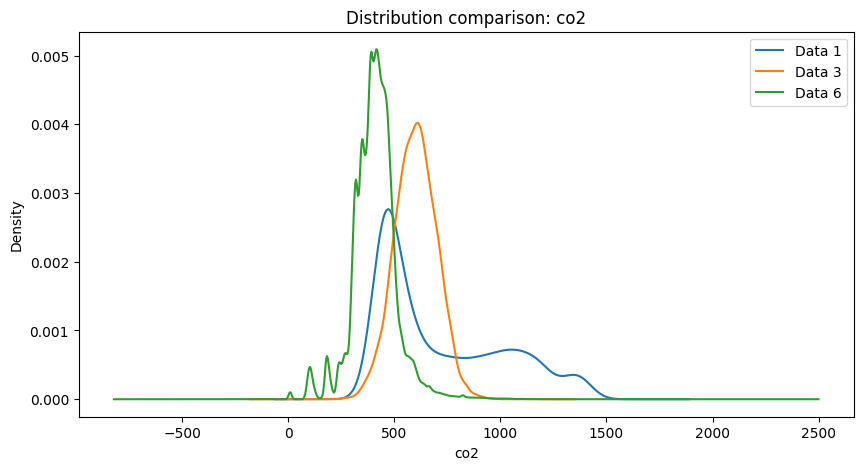

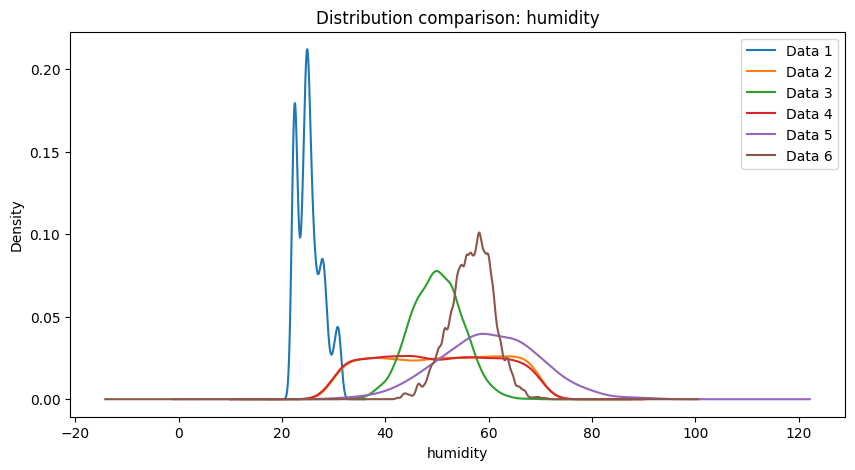

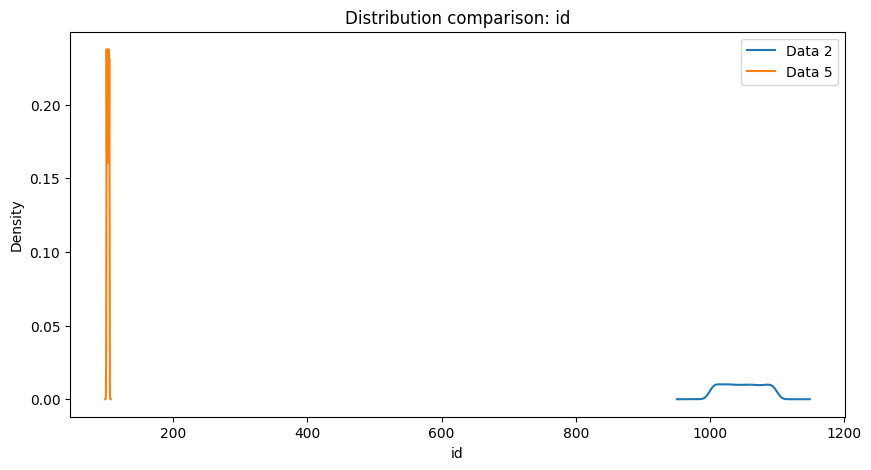

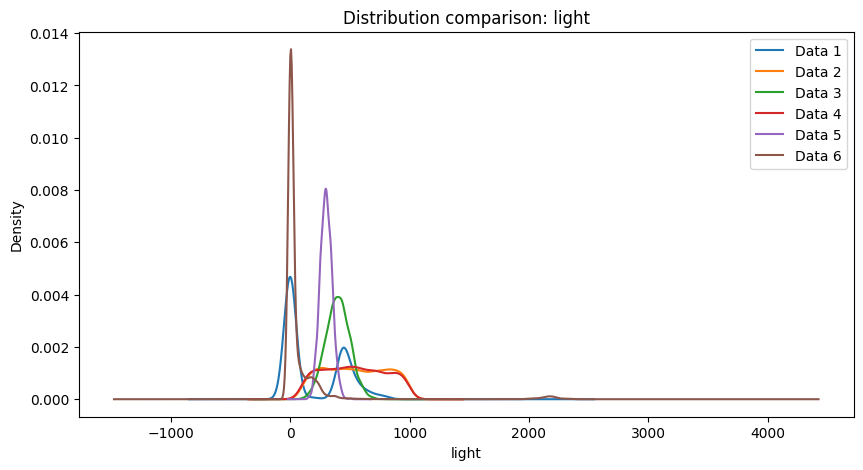

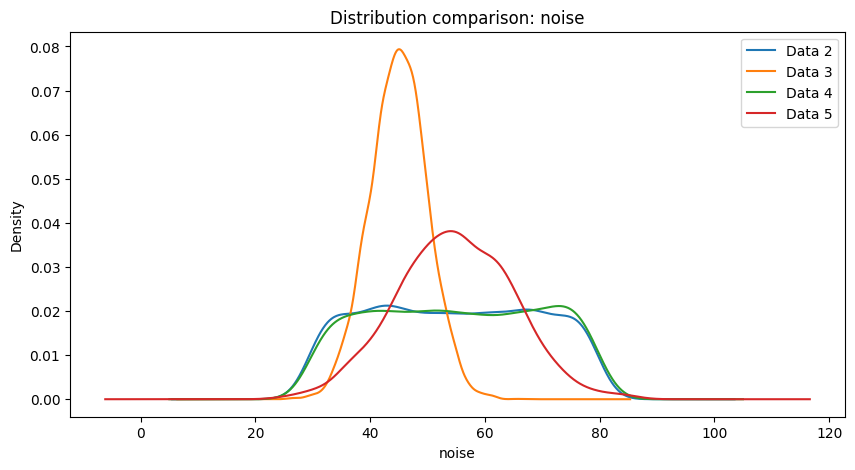

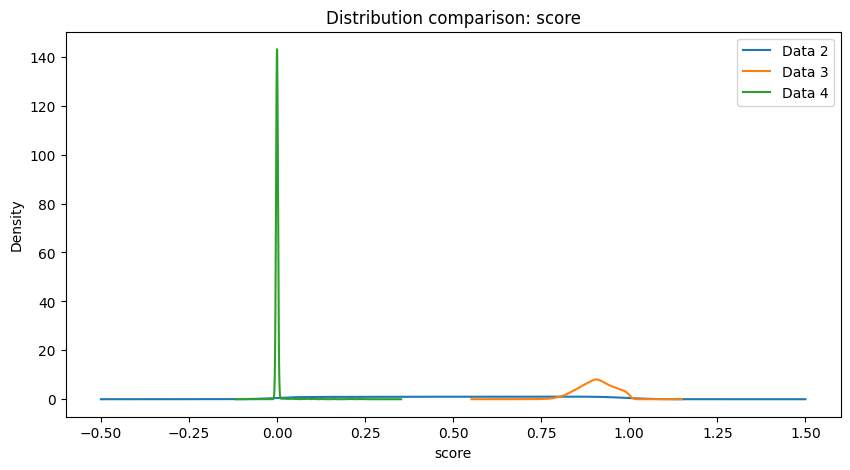

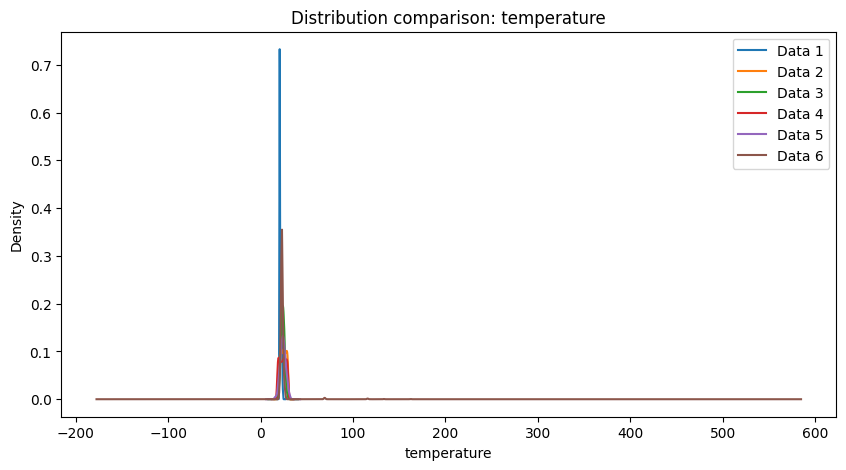

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = {
    "Data 1": data_1,
    "Data 2": data_2,
    "Data 3": data_3,
    "Data 4": data_4,
    "Data 5": data_5,
    "Data 6": data_6, 
}

# --------------------------------------------------
# 1. Quick structural overview
# --------------------------------------------------

overview = pd.DataFrame({
    name: {
        "Rows 📏": df.shape[0],
        "Columns 📚": df.shape[1],
        "Missing values ❓": df.isna().sum().sum()
    }
    for name, df in datasets.items()
}).T

display(overview)


# --------------------------------------------------
# 2. Numeric feature comparison
# Shows ranges and helps detect unit mismatches
# --------------------------------------------------

numeric_summary = []

for dataset_name, df in datasets.items():
    numeric_df = df.select_dtypes(include=np.number)

    for column in numeric_df.columns:
        numeric_summary.append({
            "Dataset": dataset_name,
            "Feature": column,
            "Min": numeric_df[column].min(),
            "Median": numeric_df[column].median(),
            "Mean": numeric_df[column].mean(),
            "Max": numeric_df[column].max(),
            "Std": numeric_df[column].std(),
        })

numeric_summary = pd.DataFrame(numeric_summary)

display(
    numeric_summary.sort_values(
        by=["Feature", "Dataset"]
    )
)


# --------------------------------------------------
# 3. Visual anomaly detection
# --------------------------------------------------

numeric_features = sorted(set(
    col
    for df in datasets.values()
    for col in df.select_dtypes(include=np.number).columns
))

for feature in numeric_features:
    plt.figure(figsize=(10, 5))

    found = False

    for name, df in datasets.items():
        if feature in df.columns and df[feature].dtype in [np.float64, np.int64]:
            df[feature].dropna().plot(
                kind="kde",
                label=name
            )
            found = True

    if found:
        plt.title(f"Distribution comparison: {feature}")
        plt.xlabel(feature)
        plt.legend()
        plt.show()

Data 1, 3, 5, 6 looks very normal (normal as of distribution and stuff). Data 2 and 4 is highly suspicious with very even distributions. 

In [88]:
# For each dataset rename id, so that we guarantee they are unique. Always insert dataset num before the id
for name, df in datasets.items():
    if 'id' in df.columns:
        # check if already has the prefix, if not add it
        if not str(df['id'].iloc[0]).startswith(name):
            df['id'] = df['id'].apply(lambda x: f"{name}_{x}")
        
# display first 5 rows of each dataset to verify id renaming
for name, df in datasets.items():
    print(f"First 5 rows of {name}:")
    display(df.head())

First 5 rows of Data 1:


,timestamp,temperature,humidity,light,co2
0,02/02/15 14:19,23.7000,26.272,585.200000,749.200000
1,02/02/15 14:19,23.7180,26.290,578.400000,760.400000
2,02/02/15 14:21,23.7300,26.230,572.666667,769.666667
3,02/02/15 14:22,23.7225,26.125,493.750000,774.750000
4,02/02/15 14:23,23.7540,26.200,488.600000,779.000000


First 5 rows of Data 2:


,timestamp,temperature,light,humidity,noise,score,id
0,2024-09-01 08:28:00,28.0,627,54.8,71,0.08,Data 2_1000
1,2024-09-01 09:40:00,25.8,938,46.3,59,0.40,Data 2_1000
2,2024-09-01 12:26:00,26.6,593,57.2,30,0.27,Data 2_1000
3,2024-09-01 12:50:00,21.3,647,64.3,37,0.03,Data 2_1000
4,2024-09-01 17:21:00,23.9,390,42.2,75,0.65,Data 2_1000


First 5 rows of Data 3:


...

,temperature,light,humidity,noise,score
0,22.494481,432.115959,43.624167,30.958646,0.234932
1,29.408572,221.965186,32.868476,68.624892,0.000000
2,26.783927,566.559664,46.385156,38.547245,0.000000
3,25.183902,201.348306,42.448700,32.195231,0.000000
4,19.872224,940.588677,57.084826,62.684935,0.000000


First 5 rows of Data 5:


,id,timestamp,temperature,humidity,noise,light
0,Data 5_104,2024-05-01 08:00:00,24.328184,62.987529,54.429034,323.015836
1,Data 5_105,2024-05-01 08:15:00,26.177300,52.482089,62.336451,412.211259
2,Data 5_103,2024-05-01 08:30:00,25.443028,55.736424,51.967691,386.972786
3,Data 5_105,2024-05-01 08:45:00,24.671652,71.484457,54.658851,339.056874
4,Data 5_105,2024-05-01 09:00:00,21.628577,61.132704,60.623440,341.460697


First 5 rows of Data 6:


,id,timestamp,temperature,humidity,light,co2
0,Data 6_413,2013-08-23 23:05:00,23.927778,45.3300,96.555556,494.727273
1,Data 6_413,2013-08-23 23:06:00,23.938333,45.3275,96.833333,496.666667
2,Data 6_413,2013-08-23 23:07:00,23.942500,45.3250,97.333333,498.916667
3,Data 6_413,2013-08-23 23:08:00,23.952500,45.3125,97.083333,504.166667
4,Data 6_413,2013-08-23 23:09:00,23.955833,45.3100,97.416667,499.500000


In [91]:
#remove score from all datasets
for name, df in datasets.items():
    if 'score' in df.columns:
        del df['score']
#combine datasets 1,3,5,6 to new dataset_combined
dataset_combined = pd.concat([datasets['Data 1'], datasets['Data 3'], datasets['Data 5'], datasets['Data 6']], axis=0).reset_index(drop=True)

#impute missing values using sklearn IterativeImputer (skip id, and timestamp columns)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer()
features = dataset_combined.drop(['id', 'timestamp'], axis=1)
imputer.fit(features)
dataset_imputed = pd.DataFrame(imputer.transform(features), columns=features.columns)
dataset_imputed['id'] = dataset_combined['id'].to_numpy()
dataset_imputed['timestamp'] = dataset_combined['timestamp'].to_numpy()

#convert into csv
dataset_imputed.to_csv('../data/mock/new/dataset_imputed.csv', index=False)

C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
